In [1]:
import numpy as np

# quantização linear
# escala: quantas unidades reais cada degrau quantizado representa
# deslocamento: qual valor inteiro corresponde ao zero real

x = 0.314
scale = 1/255 # 255 intervalos de valor
zero_point = 0

q = round(x / scale) + zero_point
dq = (q - zero_point) * scale

print("Quantizado:", q, "|", "Desquantizado:", dq)

Quantizado: 80 | Desquantizado: 0.3137254901960784


In [2]:
original_x = np.random.random(10)
print("Original:", original_x)
q_x = []
for i in original_x:
    q = round(i/scale) + zero_point
    q_x.append(q)
print("Quantizado:", q_x)

dq_x = []
for i in q_x:
    dq = (i - zero_point) * scale
    dq_x.append(dq)
    
print("Desquantizado:", dq_x)

Original: [0.42788438 0.73319001 0.05974187 0.73719651 0.90400326 0.74140695
 0.52633385 0.98884347 0.93545157 0.7617806 ]
Quantizado: [109, 187, 15, 188, 231, 189, 134, 252, 239, 194]
Desquantizado: [0.42745098039215684, 0.7333333333333333, 0.058823529411764705, 0.7372549019607844, 0.9058823529411765, 0.7411764705882353, 0.5254901960784314, 0.9882352941176471, 0.9372549019607843, 0.7607843137254902]


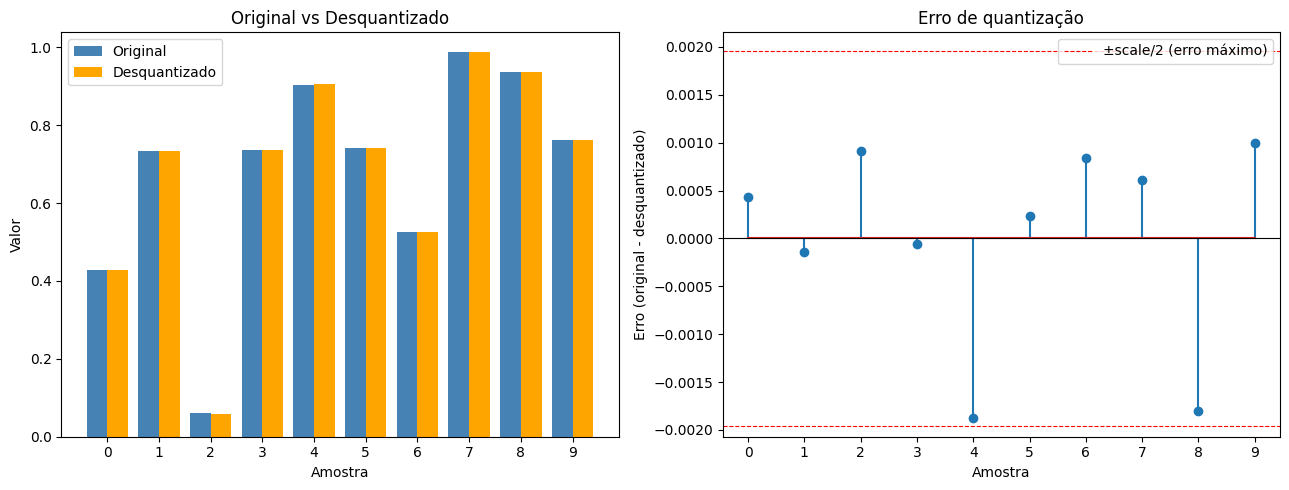

Erro absoluto médio: 0.000791
Erro absoluto máximo: 0.001879  (limite teórico = scale/2 = 0.001961)


In [3]:
import matplotlib.pyplot as plt

original_x = np.asarray(original_x)
dq_x = np.asarray(dq_x)
erro = original_x - dq_x

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Painel 1: original vs desquantizado ---
idx = np.arange(len(original_x))
largura = 0.4
ax1.bar(idx - largura / 2, original_x, largura, label="Original", color="steelblue")
ax1.bar(idx + largura / 2, dq_x, largura, label="Desquantizado", color="orange")
ax1.set_xlabel("Amostra")
ax1.set_ylabel("Valor")
ax1.set_title("Original vs Desquantizado")
ax1.set_xticks(idx)
ax1.legend()

# --- Painel 2: erro de quantização ---
ax2.stem(idx, erro)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(scale / 2, color="red", linestyle="--", linewidth=0.8, label="±scale/2 (erro máximo)")
ax2.axhline(-scale / 2, color="red", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Amostra")
ax2.set_ylabel("Erro (original - desquantizado)")
ax2.set_title("Erro de quantização")
ax2.set_xticks(idx)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Erro absoluto médio: {np.abs(erro).mean():.6f}")
print(f"Erro absoluto máximo: {np.abs(erro).max():.6f}  (limite teórico = scale/2 = {scale/2:.6f})")


In [4]:
# caso com números negativos: faixa [-1, 1] mapeada para uint8 [0, 255]
real_min, real_max = -1.0, 1.0
q_min, q_max = 0, 255

scale_neg = (real_max - real_min) / (q_max - q_min)
zero_point_neg = round(q_min - real_min / scale_neg)
print("scale:", scale_neg, "| zero_point:", zero_point_neg)

original_neg = np.random.uniform(-1, 1, 10)
print("Original:", original_neg)

q_neg = []
for i in original_neg:
    q = round(i / scale_neg) + zero_point_neg
    q_neg.append(q)
print("Quantizado:", q_neg)  # repare: nenhum valor negativo, tudo dentro de [0, 255]

dq_neg = []
for i in q_neg:
    dq = (i - zero_point_neg) * scale_neg
    dq_neg.append(dq)
print("Desquantizado:", dq_neg)


scale: 0.00784313725490196 | zero_point: 128
Original: [ 0.65482393 -0.13286429  0.64128088 -0.68682025 -0.18204761  0.30745731
 -0.66230013 -0.11412829  0.37320115  0.48992053]
Quantizado: [211, 111, 210, 40, 105, 167, 44, 113, 176, 190]
Desquantizado: [0.6509803921568628, -0.13333333333333333, 0.6431372549019607, -0.6901960784313725, -0.1803921568627451, 0.3058823529411765, -0.6588235294117647, -0.11764705882352941, 0.3764705882352941, 0.48627450980392156]


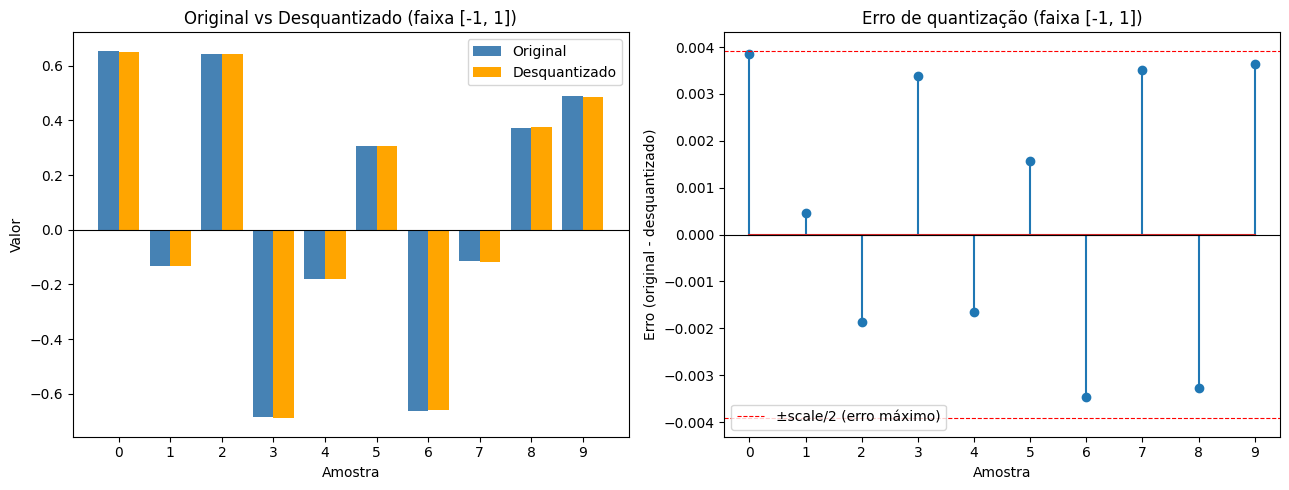

Erro absoluto médio: 0.002669
Erro absoluto máximo: 0.003844  (limite teórico = scale/2 = 0.003922)


In [5]:
original_neg = np.asarray(original_neg)
dq_neg = np.asarray(dq_neg)
erro_neg = original_neg - dq_neg

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Painel 1: original vs desquantizado ---
idx = np.arange(len(original_neg))
largura = 0.4
ax1.bar(idx - largura / 2, original_neg, largura, label="Original", color="steelblue")
ax1.bar(idx + largura / 2, dq_neg, largura, label="Desquantizado", color="orange")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Amostra")
ax1.set_ylabel("Valor")
ax1.set_title("Original vs Desquantizado (faixa [-1, 1])")
ax1.set_xticks(idx)
ax1.legend()

# --- Painel 2: erro de quantização ---
ax2.stem(idx, erro_neg)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(scale_neg / 2, color="red", linestyle="--", linewidth=0.8, label="±scale/2 (erro máximo)")
ax2.axhline(-scale_neg / 2, color="red", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Amostra")
ax2.set_ylabel("Erro (original - desquantizado)")
ax2.set_title("Erro de quantização (faixa [-1, 1])")
ax2.set_xticks(idx)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Erro absoluto médio: {np.abs(erro_neg).mean():.6f}")
print(f"Erro absoluto máximo: {np.abs(erro_neg).max():.6f}  (limite teórico = scale/2 = {scale_neg/2:.6f})")


# Tradeoffs:

- Ganha em menor uso de memória (int8/uint8 ocupa 1 byte enquanto float32 ocupa 4 bytes, 4x menor)
- Aritmética para int8/uint8 é mais rápida, movemos menos bytes entre memória e processador
- Perda de precisão, existe um erro de quantização limitado a: +- (escala / 2). A magnitude desse erro depende da largura de bits e da distribuição dos dados.
- Introduz overhead: o cálculo de quantização e desquantização.
- Introduz a necessidade de calibração da escala e do deslocamento. A faixa escolhida interfere diretamente no erro.
